In [5]:
%cd /home/smalani/PartialObservations/

from BandFModel import plot_and_metric_BandF

addon = "init-1_randomdata_onecyclelr/"
master_filename = "/home/smalani/PartialObservations/data/resonances/" + addon
save_filename = "/home/smalani/PartialObservations/Figures/blackbox_resonance/" + addon

/home/smalani/PartialObservations


In [6]:
## Black Box Resonance Trainable Metrics

%cd /home/smalani/PartialObservations
from BandFModel import plot_and_metric_BandF
import numpy as np

# RHS Hairs
L1_error_arr = []
L2_error_arr = []
Linf_error_arr = []


from config import config
config["MODEL"]["BOX"] = 'Black'
config["MODEL"]["Parameters"] = 'Fixed'

for i in range(10):
    # if i == 2 or i == 4:
    #     continue
    filename = master_filename + "model_run_" + str(i) + ".net"

    RHS_hair_error_trueLC_True, RHS_hair_error_trueLC_Pred, L1_error, L2_error, Linf_error = \
        plot_and_metric_BandF.metric_hair_fromTrue(filename=filename, make_plots=False)
    # print('===============================')
    # print(root_pred)
    # print('===============================')

    L1_error_arr.append(L1_error)
    L2_error_arr.append(L2_error)
    Linf_error_arr.append(Linf_error)

BB_bestcase = np.argmin(L2_error_arr)
print("BEST BLACK BOX RUN")
print(BB_bestcase)
print(L2_error_arr)


print("Black Box Solution Errors")
print(np.average(L1_error_arr))
print(np.std(L1_error_arr))
print('===============')
print(np.average(L2_error_arr))
print(np.std(L2_error_arr))
print('===============')
print(np.average(Linf_error_arr))
print(np.std(Linf_error_arr))

L1_error_arr = []
L2_error_arr = []
Linf_error_arr = []

for i in range(10):
    # if i == 2 or i == 4:
    #     continue
    filename = master_filename + "model_run_" + str(i) + ".net"

    root_pred = None
    output, ANN_output, output_LC, ANN_output_LC, L1_error, L2_error, Linf_error = \
        plot_and_metric_BandF.metric_RHS(filename=filename, make_plots=False)
    # print('===============================')
    # print(root_pred)
    # print('===============================')

    L1_error_arr.append(L1_error)
    L2_error_arr.append(L2_error)
    Linf_error_arr.append(Linf_error)

print("Black Box RHS Errors")
print(np.average(L1_error_arr))
print(np.std(L1_error_arr))
print('===============')
print(np.average(L2_error_arr))
print(np.std(L2_error_arr))
print('===============')
print(np.average(Linf_error_arr))
print(np.std(Linf_error_arr))

/home/smalani/PartialObservations
/home/smalani/PartialObservations/data/resonances/init-1_randomdata_onecyclelr/model_run_0.net
/home/smalani/PartialObservations/data/resonances/init-1_randomdata_onecyclelr/model_run_1.net
/home/smalani/PartialObservations/data/resonances/init-1_randomdata_onecyclelr/model_run_2.net
/home/smalani/PartialObservations/data/resonances/init-1_randomdata_onecyclelr/model_run_3.net
/home/smalani/PartialObservations/data/resonances/init-1_randomdata_onecyclelr/model_run_4.net
/home/smalani/PartialObservations/data/resonances/init-1_randomdata_onecyclelr/model_run_5.net
/home/smalani/PartialObservations/data/resonances/init-1_randomdata_onecyclelr/model_run_6.net
/home/smalani/PartialObservations/data/resonances/init-1_randomdata_onecyclelr/model_run_7.net
/home/smalani/PartialObservations/data/resonances/init-1_randomdata_onecyclelr/model_run_8.net
/home/smalani/PartialObservations/data/resonances/init-1_randomdata_onecyclelr/model_run_9.net
BEST BLACK BOX R

/home/smalani/PartialObservations
/home/smalani/PartialObservations/data/resonances/init-1_randomdata_onecyclelr/model_run_4.net


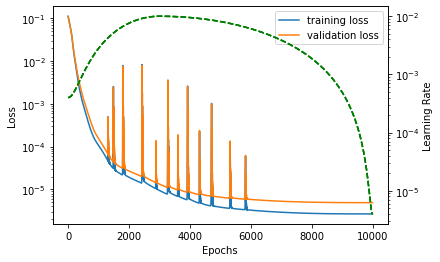

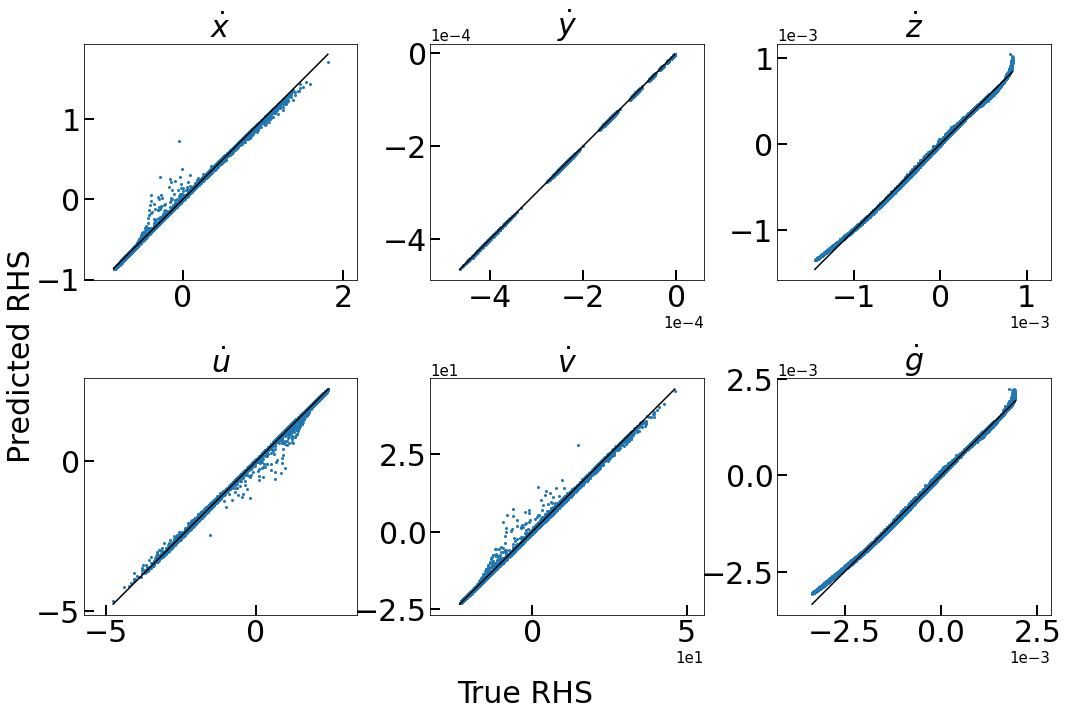

In [7]:
%cd /home/smalani/PartialObservations
# BB_bestcase = 9
from main import preprocess
from BandFModel import datagen, plot_and_metric_BandF
from config import config

import matplotlib.pyplot as plt 
import numpy as np

filename = filename = master_filename + "model_run_" + str(BB_bestcase)

train_loss = np.load(filename + '_training_loss.npy')
val_loss = np.load(filename + '_validation_loss.npy')
epoch_list = np.load(filename + '_lr_epoch.npy')
lr_list = np.load(filename + '_lr_track.npy', allow_pickle=True)

fig, ax2 = plt.subplots()
ax2.semilogy(range(train_loss.shape[0]),train_loss,label='training loss')
ax2.semilogy(range(train_loss.shape[0]),val_loss,label='validation loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
plt.legend()
ax = ax2.twinx()
ax.semilogy(epoch_list,lr_list,'g--')
ax.set_xlabel('Epochs')
ax.set_ylabel('Learning Rate')

plt.savefig(save_filename + 'TrainingCurve_' + str(BB_bestcase) + '.png')

filename = filename = master_filename + "model_run_" + str(BB_bestcase) + ".net"

output, ANN_output, output_LC, ANN_output_LC, L1_error, L2_error, Linf_error = \
        plot_and_metric_BandF.metric_RHS(filename=filename, make_plots=False)

fig = plt.figure(figsize=(15,10))

labels = ['$\dot{x}$', '$\dot{y}$', '$\dot{z}$', '$\dot{u}$', '$\dot{v}$', '$\dot{g}$']
for i in range(6):
    ax = plt.subplot(int(str(23) + str(i+1)))
    axplot = ax.scatter(output[:,i], ANN_output[:,i], s=4)
    # axplot = ax.scatter(output_LC[:,i], ANN_output_LC[:,i], s=4)
    ax.plot([np.min(output[:,i]), np.max(output[:,i])],[np.min(output[:,i]), np.max(output[:,i])], 'k-')
    # ax.tick_params(axis='y', labelsize=20)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
    ax.yaxis.offsetText.set_fontsize(15)
    ax.tick_params(axis='both', labelsize=30, direction='in', length=10, width=2)
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
    ax.xaxis.offsetText.set_fontsize(15)
    ax.set_title(labels[i], fontsize=30)
    ax.set_aspect("equal", adjustable="datalim")

# plt.suptitle('Predicted RHS vs True RHS', fontsize=40)

fig.supylabel('Predicted RHS', fontsize=30)
fig.supxlabel('True RHS', fontsize=30)
plt.tight_layout()
plt.savefig(save_filename + 'RHSPred_Model_Run_' + str(BB_bestcase) + '.png')

# plot_and_metric_BandF.make_poincare_maps(filename, make_plots=True, savefilename = 'Figures/blackbox_resonance/BB_Resonance_badinit_poincaremap_Model_Run_' + str(BB_bestcase) + '.png')

/home/smalani/PartialObservations


  0%|          | 0/2 [00:00<?, ?it/s]

pakapaaakaaa detail
(2, 6)
/home/smalani/PartialObservations/data/resonances/init-1_randomdata_onecyclelr/model_run_4.net
49


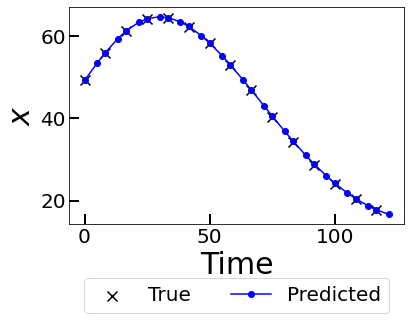

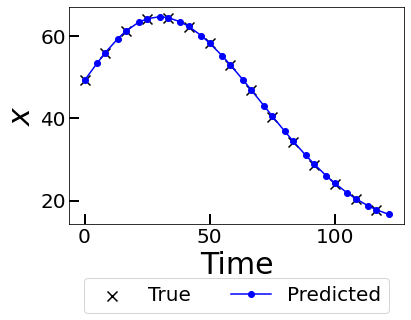

In [8]:
%cd /home/smalani/PartialObservations

from main import preprocess
from BandFModel import datagen, plot_and_metric_BandF
from config import config
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

np.random.seed(1234)



data_train = datagen.generate_data(n_train=2, duplicate_reverse=config["DATA"]["DUP_REVERSE"], detail=True)
dataset_train = preprocess.Dataset(*data_train[:2], duplicate_reverse=config["DATA"]["DUP_REVERSE"])

dataset_true = preprocess.Dataset(*data_train[:2])

# BB_bestcase = 0
filename = filename = master_filename + "model_run_" + str(BB_bestcase) + ".net"
network = plot_and_metric_BandF.load_model(filename=filename)

import torch

index = 0
print(len(dataset_true.full_times_arr[index]))

myrangefirst = 16
myrangesecond = myrangefirst + 30

x = torch.tensor(dataset_true.x[dataset_true.ids[index],myrangefirst:myrangesecond,:]).unsqueeze(0),
p = torch.tensor(dataset_true.p[dataset_true.ids[index],myrangefirst:myrangesecond,:]).unsqueeze(0),
t = torch.tensor(dataset_true.full_times_arr[dataset_true.ids[index]])[myrangefirst:myrangesecond].unsqueeze(-1).unsqueeze(0),

x_in = x[0][:,:-1,:]
t_in = t[0] - t[0][0,0,0]

network.tf_prop = 0
xout_hat = network(x_in.to(network.device), p[0].to(network.device), t_in.to(network.device), index)

plt.figure()
ax = plt.subplot(111)
ax.scatter(t_in[...,0].squeeze(),x[0][...,0].squeeze(),c='k',s=100,marker='x', label='True')
ax.plot(t_in[...,0].squeeze(),xout_hat[0][...,0].detach().cpu().numpy().squeeze(),'bo-', label='Predicted')
ax.tick_params(axis='both', labelsize=20, direction='in', length=10, width=2)
ax.set_xlabel('Time', fontsize=30)
ax.set_ylabel('$x$', fontsize=30)
lgd = ax.legend(loc='upper center', bbox_to_anchor=(0.5,-0.2), fontsize=20, ncol=2)
plt.savefig(save_filename + 'NNiter_Traj_Model_Run_' 
        + str(BB_bestcase) + '.png', bbox_extra_artists=(lgd,), bbox_inches='tight')

def ode_NN_func(t,x,p):
    x_in = torch.tensor(x).reshape((-1,6)).to(network.device)
    p_in = torch.tensor(p).reshape((-1,1)).to(network.device)
    return network.output(x_in, p_in).cpu().detach().numpy()

T = t_in[0,-1,0]
teval = t_in[0,:,0]
init = x[0][:,0,:].squeeze().numpy()
sol_pred = solve_ivp(ode_NN_func, y0=init, t_span=[0, T],
                                t_eval=teval, args=([6]),
                                rtol=1e-5, atol=1e-8)
plt.figure()
ax = plt.subplot(111)
ax.scatter(t_in[...,0].squeeze(),x[0][...,0].squeeze(),c='k',s=100,marker='x', label='True')
ax.plot(sol_pred.t,sol_pred.y[0,:],'bo-', label='Predicted')
ax.tick_params(axis='both', labelsize=20, direction='in', length=10, width=2)
ax.set_xlabel('Time', fontsize=30)
ax.set_ylabel('$x$', fontsize=30)
lgd = ax.legend(loc='upper center', bbox_to_anchor=(0.5,-0.2), fontsize=20, ncol=2)
plt.savefig(save_filename + '_solveivp_Traj_Model_Run_' 
        + str(BB_bestcase) + '.png', bbox_extra_artists=(lgd,), bbox_inches='tight')